# Molmo + SAM2 → 3D affordance grounding — step-by-step (Mug)

Take ONE object (Mug) + ONE bimanual task from the stage-1 v13.2 dataset (outputs/stage1_v2/), and verify the
downstream grounding **step by step**:

1. **canvas = affogato's raw point cloud** for this object (`xyzc.npy`) — we do NOT rebuild a cloud by
   back-projecting depth; we vote onto the existing affogato points,
2. **Molmo** points to each role's contact region in every gObjaverse view,
3. **SAM2** turns each point into a per-view mask/heatmap,
4. multi-view **voting** maps the per-view heatmaps back onto the affogato canvas points,
5. visualize the two coordinated hand regions (role A + role B) on the object, and compare against the
   affogato GT affordance channels.

Reuses the validated functions in `pipeline/single_region_affordance.py` (`process_object`'s exact path:
load `xyzc.npy` → align frame → vote). Run with the **mm** conda env.

## 0 · Setup (env, GPU, imports)
GPU 2 is free (GPU 1 is used by another user, GPU 3 by the stage-1 run). Pin it before importing torch.

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "3"          # free 24GB card; Molmo-8B + SAM2 fit
os.environ["CUDA_DEVICE_ORDER"]   = "PCI_BUS_ID"  # match nvidia-smi ordering
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"      # needed before cv2 reads the depth EXR

DG = "/home/michaellee/mclee/affogato/data_generation"
sys.path.insert(0, DG)
os.chdir(DG)   # so PipelineConfig's relative checkpoints/ + configs/ paths resolve

import numpy as np, json, cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torch
import single_region.single_region_affordance as sra   # validated geometry/Molmo/SAM2/voting fns

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.8.0+cu128 | cuda True | device NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## 1 · Pick the object, load its bimanual task + the affogato canvas
The stage-1 `object_id` is the affogato/objaverse UID. `daily_used_to_affogato.json` maps the
gObjaverse render folder (`src`) ↔ the affogato dir (`dst`, holding `xyzc.npy` + `queries.json`).

In [2]:
OBJ_ID = "849b4573e03a40b8b073a2209d1bc1d3"   # Mug

# stage-1 record (our bimanual tasks + per-role molmo_queries)
rec = next(o for o in json.load(open(f"{DG}/outputs/stage1_v2/stage1_part0.json"))
           if o["object_id"] == OBJ_ID)
OBJ_ROOT = "/".join(rec["views_used"][0].split("/")[:-2])   # gObjaverse render folder

# affogato canvas dir (dst) via the mapping
mp = json.load(open(f"{DG}/dataset/daily_used_to_affogato.json"))
AFF = next(e["dst"] for e in mp if e["object_id"] == OBJ_ID)

print("OBJECT  :", rec["object_name"], "| components:", [c["name"] for c in rec["components"]])
print("renders :", OBJ_ROOT)
print("affogato:", AFF)
for i, q in enumerate(rec["queries"]):
    print(f"  [{i}] ({q['category']}) {q['task']}")

# --- choose the task to ground (0 = 'pick up the Mug': lift handle + support body) ---
QUERY_IDX = 0
query = rec["queries"][QUERY_IDX]
print("\nGrounding task:", query["task"])
for r, mq in zip(query["roles"], query["molmo_queries"]):
    print(f"  hand {r['id']}: {r['role']:6s} {r['target']:6s} @ {r['contact_region']}")
    print(f"           molmo_query: {mq}")

OBJECT  : Mug | components: ['body', 'handle', 'rim']
renders : /nfs_drive/gobjaverse/daily-used/52/272590
affogato: /home/michaellee/mclee/affogato/dataset/affogato/affogato_all_part004/849b4573e03a40b8b073a2209d1bc1d3
  [0] (inter) pick up the Mug
  [1] (inter) tip out contents
  [2] (intra) levelly transport the mug
  [3] (intra) rotate the mug by the handle and body

Grounding task: pick up the Mug
  hand A: lift   handle @ the center of the handle loop
           molmo_query: Point to the center of the handle loop where a robot hand should lift it to actuate the upward lift by grasping the handle.
  hand B: support body   @ the mid-height of the side wall opposite the handle
           molmo_query: Point to the mid-height of the side wall opposite the handle where a robot hand should support it to steady the mug and assist the lift by supporting the body.


## 2 · Load the affogato canvas + camera params
`xyzc.npy` = [N,3] xyz + [N,K] GT affordance channels. The affogato points use a different axis
convention than the gObjaverse cameras, so we align them once (**swap Y/Z, flip new Y** — exactly
`process_object`'s `align_gt_frame`) to get `xyz_vote`; `gt[i]` stays attached to point `i`. Camera
extrinsics / intrinsics / render-depth come from the gObjaverse views (for the visibility test).

In [3]:
xyzc = np.load(f"{AFF}/xyzc.npy").astype(np.float32)
xyz, gt = xyzc[:, :3], xyzc[:, 3:]                       # canvas points + GT affordance channels
gt_meta = json.load(open(f"{AFF}/queries.json"))[0]
gt_queries = gt_meta["queries"]
print("canvas:", xyz.shape, "| GT channels:", gt.shape[1], "| class:", gt_meta.get("class_name"))

# align affogato frame -> gObjaverse camera frame (required before projecting/voting)
xyz_vote = xyz[:, [0, 2, 1]].copy(); xyz_vote[:, 1] *= -1

NUM_VIEWS = min(sra.count_available_views(OBJ_ROOT), 40)
view_images, view_images_np = sra.load_view_images(OBJ_ROOT, NUM_VIEWS)
cameras, K_list, depth_maps = sra.prepare_camera_params(OBJ_ROOT, NUM_VIEWS)   # (c2w, w2c=inv(c2w_conv)), K, depth
print(f"using {NUM_VIEWS} views for voting")

canvas: (16384, 3) | GT channels: 5 | class: Mug


Preparing camera matrices: 100%|██████████| 40/40 [00:00<00:00, 42.06it/s]

using 40 views for voting


**Verify the canvas** — the affogato point cloud should look like the Mug.

In [4]:
def show_cloud(xyz, color, title, cmin=None, cmax=None, colorscale=None, colorbar=False, size=1.0):
    s = slice(None, None, max(1, len(xyz)//60000))
    marker = dict(size=size, opacity=0.85)
    if colorscale is None:
        marker["color"] = color                          # fixed color string or rgb array
    else:
        marker.update(color=color[s], colorscale=colorscale, cmin=cmin, cmax=cmax,
                      colorbar=(dict(title="score") if colorbar else None))
    fig = go.Figure(go.Scatter3d(x=xyz[s,0], y=xyz[s,1], z=xyz[s,2], mode="markers", marker=marker))
    fig.update_layout(title=title, width=820, height=620,
                      scene=dict(aspectmode="data"), margin=dict(l=0,r=0,t=30,b=0))
    return fig

show_cloud(xyz, "lightslategrey", f"{rec['object_name']} — affogato canvas ({len(xyz):,} pts)").show()

## 3 · Load Molmo + SAM2
`load_models` loads MolmoPoint-8B + SAM2.1-hiera-large onto the pinned GPU (≈1–2 min the first time).

In [5]:
cfg = sra.PipelineConfig(num_views=NUM_VIEWS)     # defaults: best_iou mask, gaussian sigma=77, depth_tol=0.15
models = sra.load_models(cfg)
print("loaded:", cfg.molmo_model_id, "+", os.path.basename(cfg.sam2_checkpoint))

I0000 00:00:1780887195.905427 2657164 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780887195.979838 2657164 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Loading Molmo model: allenai/MolmoPoint-8B ...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
<unknown>:62: SyntaxWarning: invalid escape sequence '\d'


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Loading SAM2: checkpoints/sam2.1_hiera_large.pt ...
loaded: allenai/MolmoPoint-8B + sam2.1_hiera_large.pt


## 4 · One reusable grounding step
`ground(molmo_query)` runs the full chain for one `"Point to ..."` phrase and returns the
intermediates so we can inspect each: per-view Molmo points → per-view SAM2 heatmaps → per-canvas-point
score. Voting uses the **aligned** `xyz_vote`, so `scores[i]` corresponds to canvas point `xyz[i]`.

In [6]:
def ground(molmo_query):
    pts_per_view = sra.run_molmo_single_query(view_images, molmo_query, models, cfg)
    heatmaps     = sra.run_sam2_single_query(view_images_np, pts_per_view, models.sam2_predictor, cfg)
    scores, counts = sra.project_and_sample_heatmaps(xyz_vote, heatmaps, cameras, K_list, depth_maps, cfg.depth_tolerance)
    hit = sum(len(p) > 0 for p in pts_per_view)
    print(f"  Molmo hit {hit}/{NUM_VIEWS} views | score [{scores.min():.3f}, {scores.max():.3f}] "
          f"mean {scores.mean():.3f} | coverage {(counts>0).mean()*100:.0f}%")
    return pts_per_view, heatmaps, scores

# --- ground role B of the chosen task (its role + molmo_query are printed below) ---
roleB = query["roles"][1]; mqB = query["molmo_queries"][1]
print("role B molmo_query:", mqB)
ptsB, hmB, scoreB = ground(mqB)

role B molmo_query: Point to the mid-height of the side wall opposite the handle where a robot hand should support it to steady the mug and assist the lift by supporting the body.


MolmoPoint: 100%|██████████| 40/40 [01:02<00:00,  1.56s/it]


  views with a point: 31/40


SAM2 heatmaps: 100%|██████████| 40/40 [00:03<00:00, 10.01it/s]

  Molmo hit 31/40 views | score [0.000, 0.946] mean 0.659 | coverage 100%


**Verify Molmo** — the predicted point should land on role B's contact_region in each view.

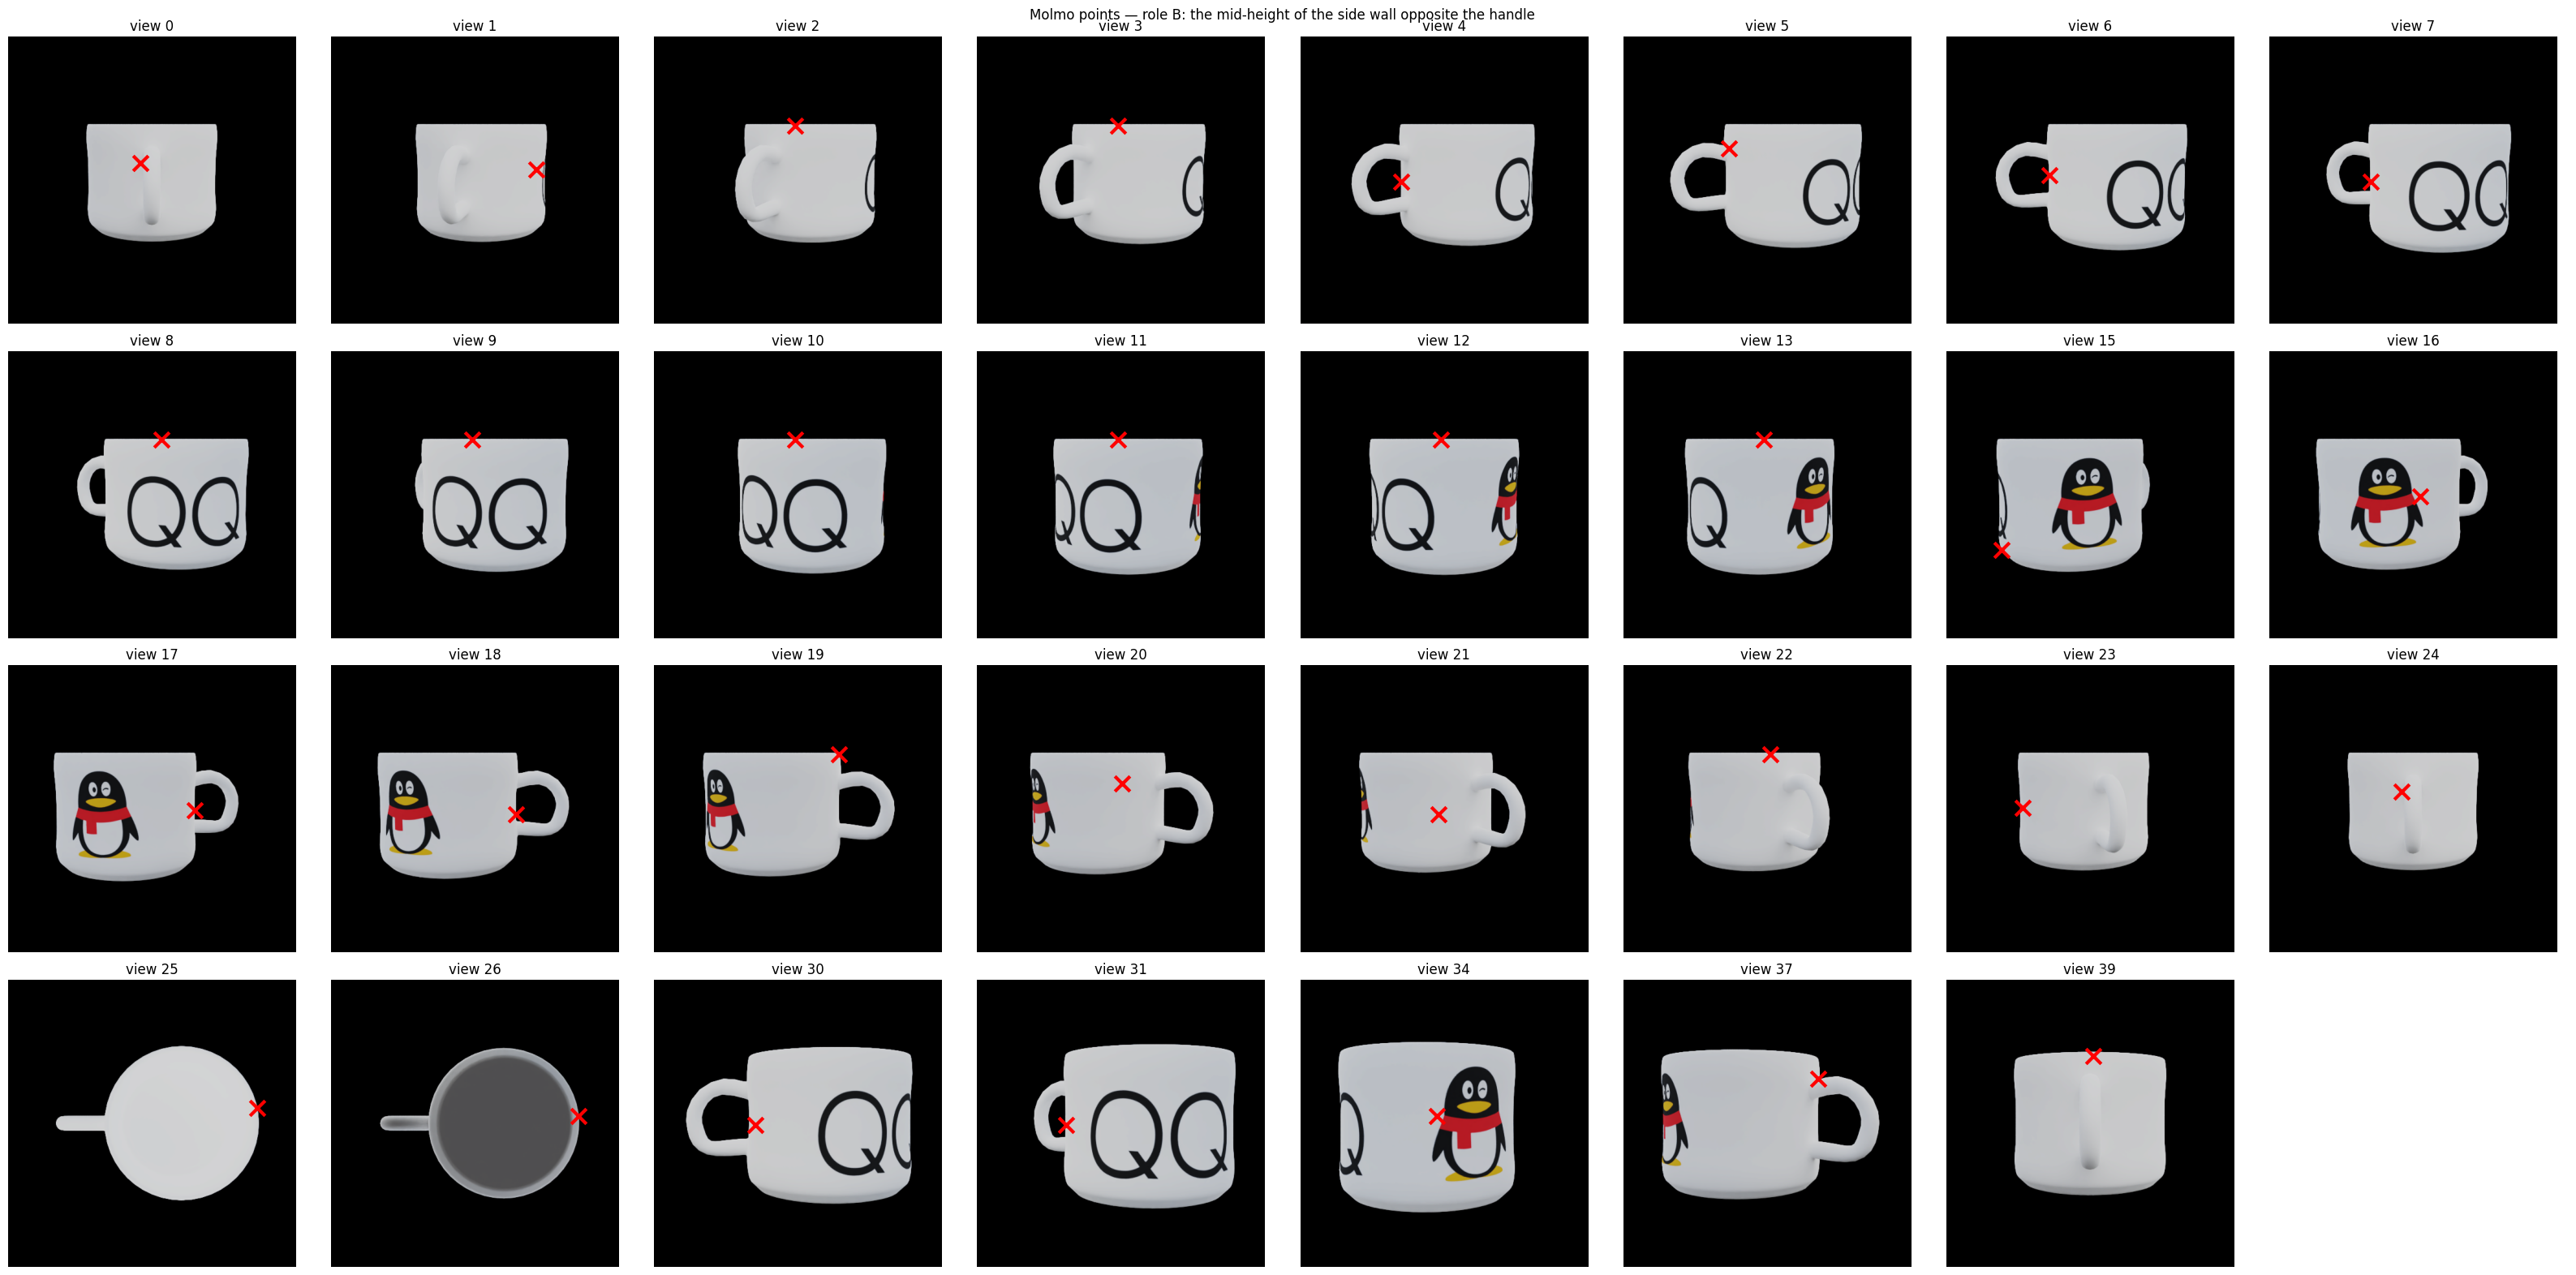

In [7]:
def show_points_on_views(pts_per_view, title, n=6):
    have = [i for i, p in enumerate(pts_per_view) if len(p) > 0][:n]
    if not have: print("no Molmo points to show"); return
    cols = min(8, len(have)); rows = (len(have)+cols-1)//cols
    fig, ax = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)); ax = np.atleast_1d(ax).ravel()
    for k, vi in enumerate(have):
        ax[k].imshow(view_images_np[vi])
        for (x, y) in pts_per_view[vi]:
            ax[k].scatter([x], [y], s=180, marker="x", c="red", linewidths=3)
        ax[k].set_title(f"view {vi}"); ax[k].axis("off")
    for k in range(len(have), len(ax)): ax[k].axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_points_on_views(ptsB, f"Molmo points — role B: {roleB['contact_region']}", n=NUM_VIEWS)

**Verify SAM2** — each Molmo point should expand to a mask covering that region.

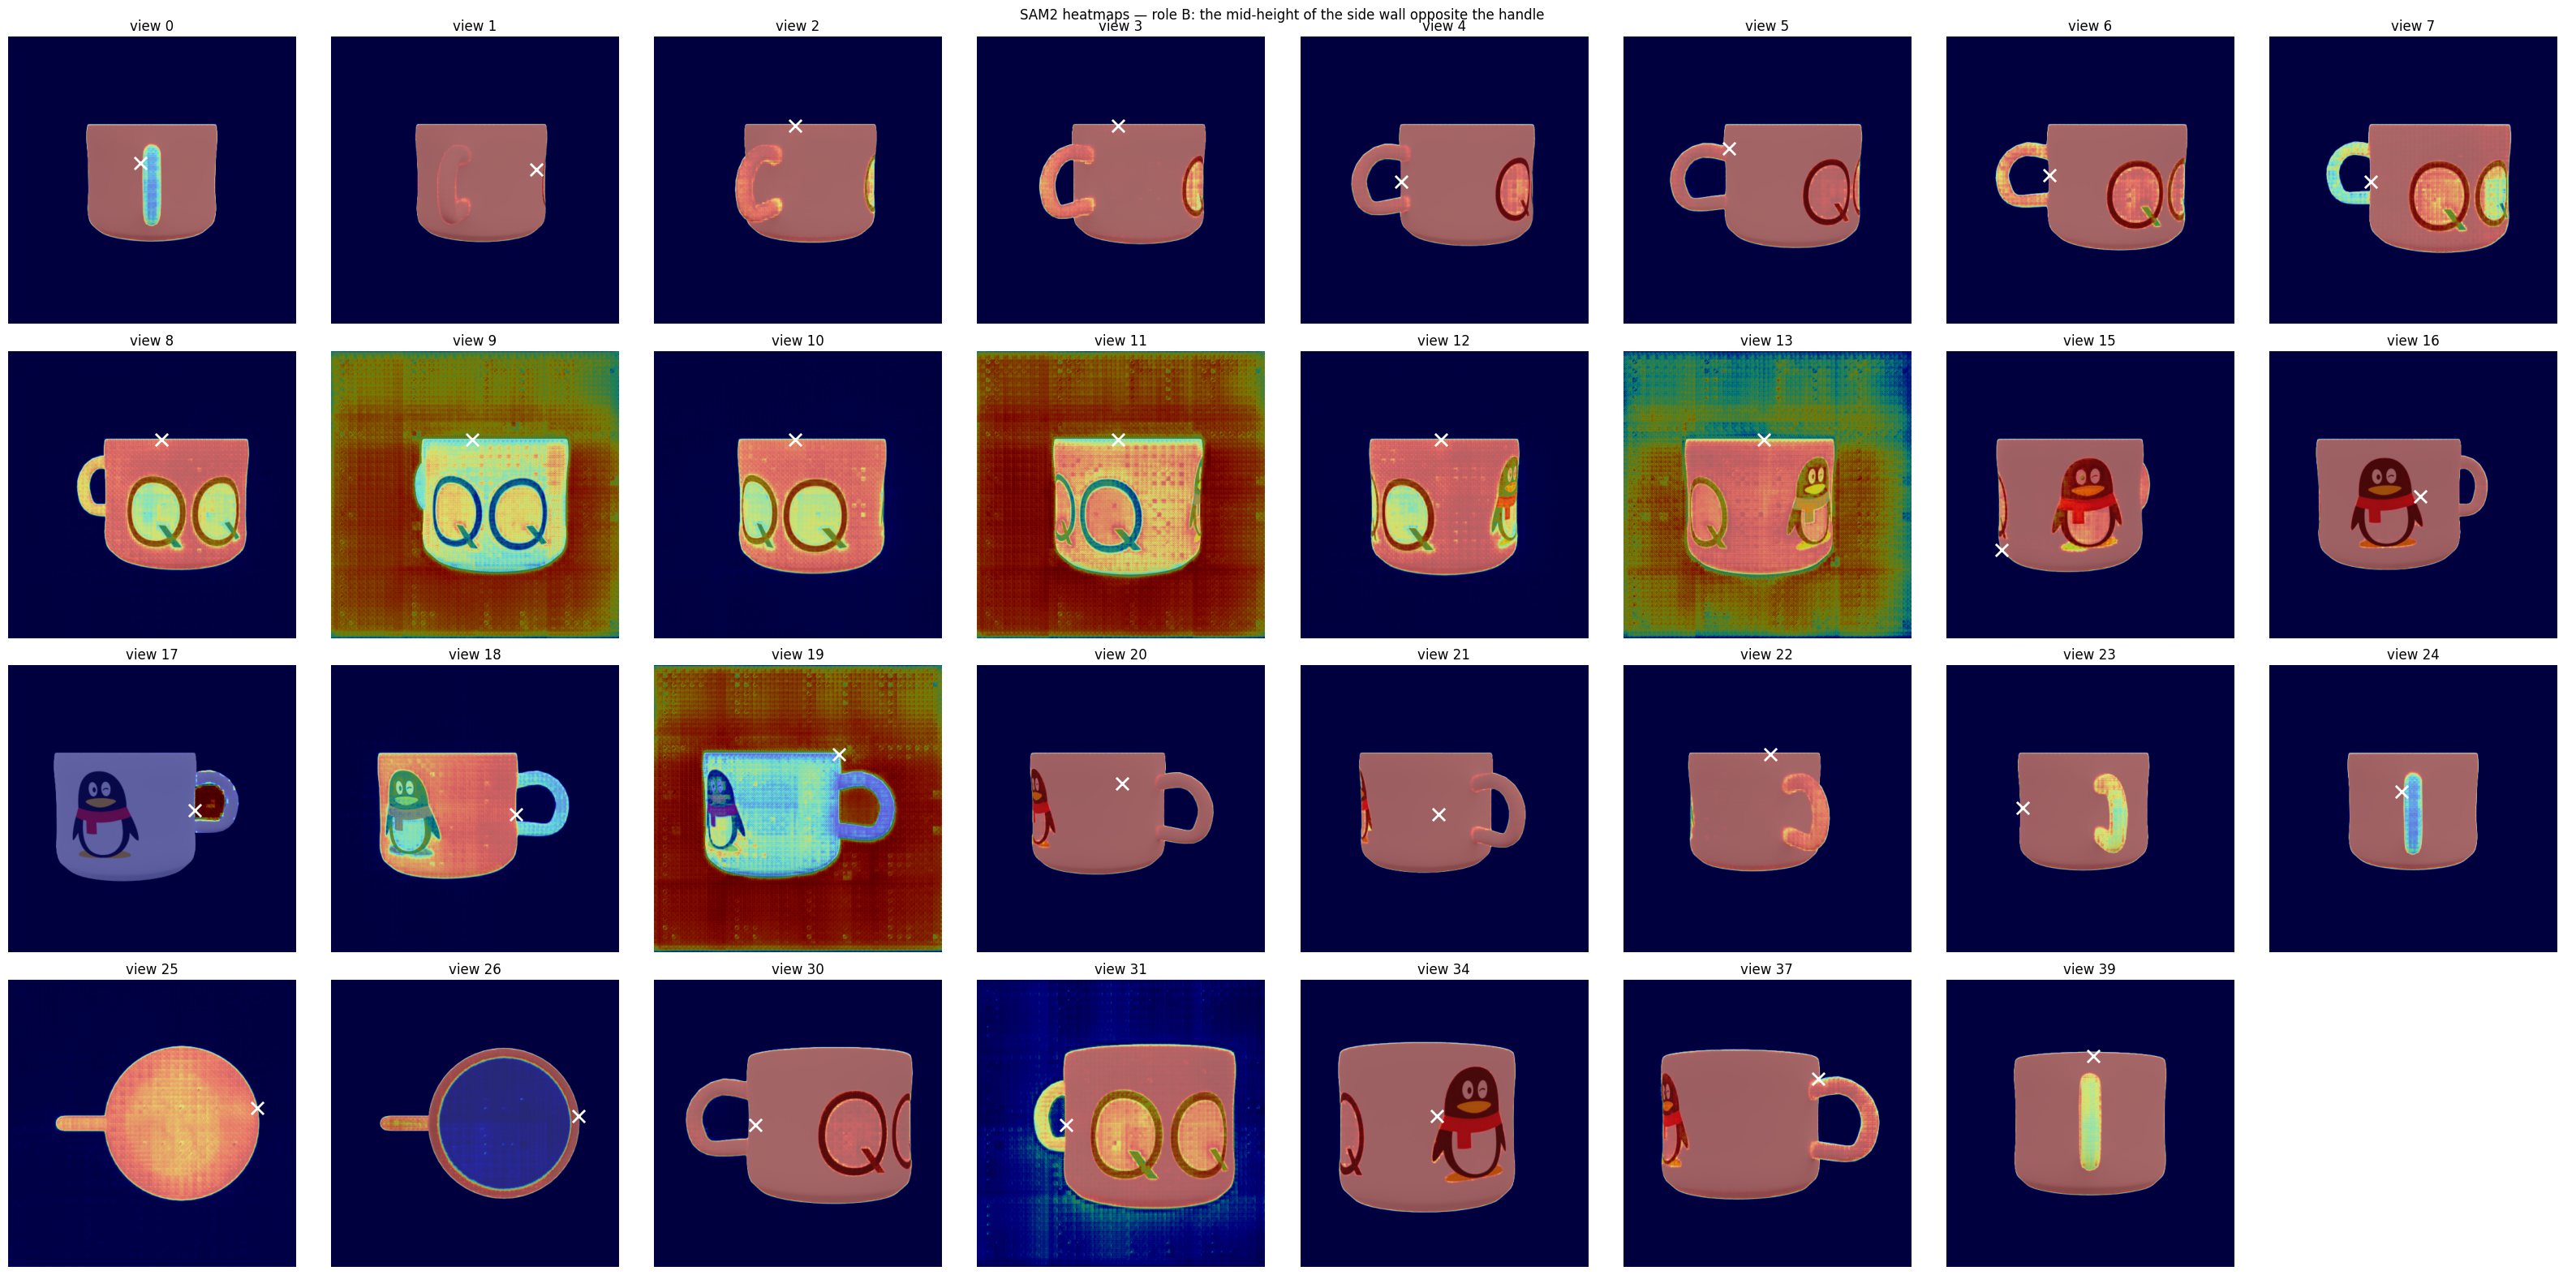

In [8]:
def show_heatmaps_on_views(pts_per_view, heatmaps, title, n=6):
    have = [i for i, p in enumerate(pts_per_view) if len(p) > 0][:n]
    if not have: print("no masks to show"); return
    cols = min(8, len(have)); rows = (len(have)+cols-1)//cols
    fig, ax = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)); ax = np.atleast_1d(ax).ravel()
    for k, vi in enumerate(have):
        ax[k].imshow(view_images_np[vi])
        ax[k].imshow(heatmaps[vi], cmap="jet", alpha=0.5, vmin=0, vmax=1)
        for (x, y) in pts_per_view[vi]:
            ax[k].scatter([x], [y], s=120, marker="x", c="white", linewidths=2)
        ax[k].set_title(f"view {vi}"); ax[k].axis("off")
    for k in range(len(have), len(ax)): ax[k].axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_heatmaps_on_views(ptsB, hmB, f"SAM2 heatmaps — role B: {roleB['contact_region']}", n=NUM_VIEWS)

**Verify voting** — per-view masks fuse into a 3D heatmap on the affogato canvas (role B's region lights up).

In [9]:
show_cloud(xyz, scoreB, f"Role B affordance: {roleB['role']} @ {roleB['contact_region']}",
           cmin=0, cmax=max(0.2, float(scoreB.max())), colorscale="Jet", colorbar=True).show()

## 5 · The bimanual pair — both hands together
Run role A too, and show both coordinated regions on the canvas: this is the
two-region affordance the dataset is meant to produce.

In [10]:
roleA = query["roles"][0]; mqA = query["molmo_queries"][0]
print("role A molmo_query:", mqA)
ptsA, hmA, scoreA = ground(mqA)

role A molmo_query: Point to the center of the handle loop where a robot hand should lift it to actuate the upward lift by grasping the handle.


MolmoPoint: 100%|██████████| 40/40 [01:41<00:00,  2.55s/it]


  views with a point: 38/40


SAM2 heatmaps: 100%|██████████| 40/40 [00:04<00:00,  9.98it/s]

  Molmo hit 38/40 views | score [0.000, 0.962] mean 0.169 | coverage 100%


In [11]:
# --- bimanual color scheme: role A = orange, role B = tiffany green ---
ORANGE,  TIFFANY  = "#F28E2B", "#0ABAB5"                # solid hues for the labels
ORANGE_SCALE  = [[0.0, "#FBDDB6"], [1.0, ORANGE]]       # light tint -> orange   (role A)
TIFFANY_SCALE = [[0.0, "#BFE9E6"], [1.0, TIFFANY]]      # light tint -> tiffany  (role B)

def two_role_fig(xyz, sA, sB, labelA, labelB, task_query, thr=0.15):
    s = slice(None, None, max(1, len(xyz)//60000))
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=xyz[s,0],y=xyz[s,1],z=xyz[s,2],mode="markers",
        marker=dict(size=1.2,color="lightgrey",opacity=0.25),name="object",hoverinfo="skip"))
    for sc, name, scale in [(sA,labelA,ORANGE_SCALE),(sB,labelB,TIFFANY_SCALE)]:
        m = sc[s] > thr
        fig.add_trace(go.Scatter3d(x=xyz[s][m,0],y=xyz[s][m,1],z=xyz[s][m,2],mode="markers",
            marker=dict(size=1.2,color=sc[s][m],colorscale=scale,cmin=thr,
                        cmax=max(thr+0.05,float(sc.max())),opacity=0.9),name=name))

    # title as a centered block with left-aligned lines (annotation: xanchor center -> block is centered,
    # align left -> lines sit flush-left under each other): task query (neutral) + each role tag, colored
    title = (f'<b>Task query:</b> "{task_query}"<br>'
             + f"<span style='color:{ORANGE}'>Role A - {labelA}</span><br>"
             + f"<span style='color:{TIFFANY}'>Role B - {labelB}</span>")
    fig.add_annotation(text=title, xref="paper", yref="paper",
                       x=0.5, xanchor="center", y=1.02, yanchor="bottom",
                       align="left", showarrow=False, font=dict(size=13))

    fig.update_layout(
        width=860, height=720, scene=dict(aspectmode="data"),
        margin=dict(l=0, r=0, t=100, b=0), showlegend=False)
    return fig

two_role_fig(xyz, scoreA, scoreB,
             f"{roleA['role']} @ {roleA['contact_region']}",
             f"{roleB['role']} @ {roleB['contact_region']}",
             query["query"]).show()

## 5.5 · Resolve the two-role overlap → two distinct regions
Molmo grounds each role's contact_region independently, so a **symmetric co-lift** (both hands on the
body's opposite faces) collapses onto one region, and an **asymmetric** grasp can overlap at the part
boundary. `sra.partition_two_roles` fixes this with a structure-driven split keyed on whether the two
roles target the SAME part: same part → union + split into two opposite halves; different parts → make
disjoint. Compare against the raw figure above.

In [12]:
scoreA_p, scoreB_p = sra.partition_two_roles(scoreA, scoreB, roleA, roleB, xyz)
two_role_fig(xyz, scoreA_p, scoreB_p,
             f"{roleA['role']} @ {roleA['contact_region']}",
             f"{roleB['role']} @ {roleB['contact_region']}",
             query["query"]).show()

## 6 · Reference — affogato GT affordance channels
Bonus sanity check: the affogato canvas ships 5 GT affordance channels (single-region, different
queries than ours). Render one to confirm the canvas + colormap behave, and to eyeball where GT puts
e.g. the affogato GT lift region vs where our pipeline puts each role.

In [ ]:
print("affogato GT queries:")
for i, gq in enumerate(gt_queries): print(f"  [{i}] {gq}")
GT_IDX = 2   # e.g. 'Point to the handle you would use to lift it.'
show_cloud(xyz, gt[:, GT_IDX], f"affogato GT[{GT_IDX}]: {gt_queries[GT_IDX]}",
           cmin=0, cmax=max(0.2, float(gt[:, GT_IDX].max())), colorscale="Viridis", colorbar=True).show()

## 7 · Notes / next steps
- Swap `QUERY_IDX` to ground other tasks (unlock = `rotate` the screw-like lock on the front, etc.).
- `cfg` knobs to compare: `mask_select` (`best_iou` vs `smallest`), `use_gaussian` / `gaussian_sigma`,
  `depth_tolerance`, `num_views`.
- To batch every query + persist scores, mirror `single_region_affordance.process_object` / `save_result`
  (writes `affordance_pred.npz` = pred/counts/xyz). That path also scores affogato's OWN queries against
  the GT channels (the validated AUC 0.78/0.83 reproduction).